## 1. Setup & Imports

**Key Points:**
1. **First:** HMM learns from corpus (statistical patterns)
2. **Then:** Q-Learning agent trains using HMM guidance
3. **Result:** Hybrid model combining statistics + reinforcement learning

In [ ]:
import os
import re
import random
import string
from pathlib import Path
from collections import Counter, defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from itertools import combinations

random.seed(42)
np.random.seed(42)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

print(' All libraries imported!')
print(f'Working directory: {os.getcwd()}')

 All libraries imported!
Working directory: /content


## 2. Load Data

In [ ]:
def find_data_file(filename):
    candidates = [
        Path(filename),
        Path('Data') / 'Data' / filename,
        Path('Data') / filename,
    ]

    for path in candidates:
        if path.exists():
            print(f'✓ Found {filename} at: {path.absolute()}')
            return path

    for root, dirs, files in os.walk('.', topdown=True):
        if filename in files:
            found_path = Path(root) / filename
            print(f'✓ Found {filename} at: {found_path.absolute()}')
            return found_path

    raise FileNotFoundError(f'❌ Could not locate {filename}')

corpus_path = find_data_file('corpus.txt')
test_path = find_data_file('test.txt')

with open(corpus_path, 'r', encoding='utf-8') as f:
    corpus_words = [line.strip().lower() for line in f if line.strip()]

with open(test_path, 'r', encoding='utf-8') as f:
    test_words = [line.strip().lower() for line in f if line.strip()]

print(f'\n Dataset:')
print(f'   Corpus: {len(corpus_words):,} words')
print(f'   Test: {len(test_words):,} words')

✓ Found corpus.txt at: /content/corpus.txt
✓ Found test.txt at: /content/test.txt

 Dataset:
   Corpus: 50,000 words
   Test: 2,000 words


## 3. Hangman Game Environment

In [ ]:
class HangmanGame:
    def __init__(self, word, max_wrong_guesses=6):
        self.word = word.lower()
        self.word_length = len(self.word)
        self.max_wrong_guesses = max_wrong_guesses
        self.reset()

    def reset(self):
        self.guessed_letters = set()
        self.wrong_guesses = 0
        self.repeated_guesses = 0
        self.current_state = '_' * self.word_length
        self.game_over = False
        self.won = False
        return self.get_state()

    def get_state(self):
        return {
            'word_state': self.current_state,
            'guessed_letters': list(self.guessed_letters),
            'wrong_guesses': self.wrong_guesses,
            'lives_remaining': self.max_wrong_guesses - self.wrong_guesses,
            'game_over': self.game_over,
            'won': self.won
        }

    def guess(self, letter):
        letter = letter.lower()

        if letter in self.guessed_letters:
            self.repeated_guesses += 1
            return self.get_state(), -10, self.game_over

        self.guessed_letters.add(letter)

        if letter in self.word:
            new_state = list(self.current_state)
            for i, char in enumerate(self.word):
                if char == letter:
                    new_state[i] = letter
            self.current_state = ''.join(new_state)

            if '_' not in self.current_state:
                self.game_over = True
                self.won = True
                return self.get_state(), 100, True

            return self.get_state(), 10, False
        else:
            self.wrong_guesses += 1

            if self.wrong_guesses >= self.max_wrong_guesses:
                self.game_over = True
                self.won = False
                return self.get_state(), -50, True

            return self.get_state(), -5, False

print(' Game environment created')

 Game environment created


## 4. Hidden Markov Model Training on Corpus

**First step:** Build and train the HMM on corpus.txt before any RL training.

The HMM learns statistical patterns from 50,000 training words including:
- N-gram patterns (bigrams, trigrams)
- Position-aware letter frequencies
- Word-length clustering

This trained HMM will later guide the Q-Learning agent.

In [ ]:
class AdvancedHMMGuesser:
    """Advanced HMM with n-grams, position awareness, and co-occurrence"""

    def __init__(self, corpus_words):
        self.corpus_words = corpus_words
        self.words_by_length = defaultdict(list)
        self.letter_freq = Counter()
        self.position_freq = defaultdict(Counter)  # letter frequency by position
        self.bigrams = defaultdict(Counter)  # bigram patterns
        self.trigrams = defaultdict(Counter)  # trigram patterns
        self.vowels = set('aeiou')

        # Build comprehensive statistics
        for word in corpus_words:
            self.words_by_length[len(word)].append(word)

            # Letter frequencies
            for i, letter in enumerate(word):
                self.letter_freq[letter] += 1
                self.position_freq[i][letter] += 1

            # Bigrams
            for i in range(len(word) - 1):
                self.bigrams[word[i]][word[i+1]] += 1

            # Trigrams
            for i in range(len(word) - 2):
                key = (word[i], word[i+2])
                self.trigrams[key][word[i+1]] += 1

        print(f' Advanced HMM initialized')
        print(f'   Words: {len(corpus_words):,}')
        print(f'   Bigrams: {len(self.bigrams):,}')
        print(f'   Trigrams: {len(self.trigrams):,}')

    def get_matching_words(self, word_state, guessed_letters):
        word_length = len(word_state)
        candidates = self.words_by_length[word_length]

        matching = []
        for word in candidates:
            match = True
            for i, char in enumerate(word_state):
                if char != '_' and word[i] != char:
                    match = False
                    break
                if char == '_' and word[i] in guessed_letters:
                    match = False
                    break
            if match:
                matching.append(word)

        return matching

    def predict_with_ngrams(self, word_state, guessed_letters):
        """Use bigrams and trigrams for prediction"""
        scores = defaultdict(float)

        for i, char in enumerate(word_state):
            if char == '_':
                continue

            # Bigram: look ahead
            if i + 1 < len(word_state) and word_state[i+1] == '_':
                for letter, count in self.bigrams[char].items():
                    if letter not in guessed_letters:
                        scores[letter] += count * 2

            # Bigram: look behind
            if i > 0 and word_state[i-1] == '_':
                for prev_letter in string.ascii_lowercase:
                    if prev_letter not in guessed_letters:
                        scores[prev_letter] += self.bigrams[prev_letter][char]

            # Trigram: middle letter
            if i > 0 and i + 1 < len(word_state):
                if word_state[i-1] != '_' and word_state[i+1] == '_':
                    key = (word_state[i-1], char)
                    for letter, count in self.trigrams.get(key, {}).items():
                        if letter not in guessed_letters:
                            scores[letter] += count * 3

        if scores:
            return max(scores, key=scores.get)
        return None

    def predict_with_position(self, word_state, guessed_letters):
        """Use position-aware frequency"""
        scores = defaultdict(float)

        for i, char in enumerate(word_state):
            if char == '_':
                for letter, count in self.position_freq[i].items():
                    if letter not in guessed_letters:
                        scores[letter] += count

        if scores:
            return max(scores, key=scores.get)
        return None

    def predict_letter(self, word_state, guessed_letters):
        """Multi-strategy prediction with fallback"""
        available = [l for l in string.ascii_lowercase if l not in guessed_letters]
        if not available:
            return None

        # Strategy 1: Start with most common vowel
        if len(guessed_letters) == 0:
            return 'e'  # Most common letter in English

        # Strategy 2: Pattern matching with corpus
        matching_words = self.get_matching_words(word_state, guessed_letters)

        if matching_words:
            letter_counts = Counter()
            for word in matching_words:
                for letter in word:
                    if letter not in guessed_letters:
                        letter_counts[letter] += 1

            if letter_counts:
                return letter_counts.most_common(1)[0][0]

        # Strategy 3: N-gram patterns
        revealed_count = sum(1 for c in word_state if c != '_')
        if revealed_count >= 1:
            ngram_pred = self.predict_with_ngrams(word_state, guessed_letters)
            if ngram_pred:
                return ngram_pred

        # Strategy 4: Position-aware frequency
        pos_pred = self.predict_with_position(word_state, guessed_letters)
        if pos_pred:
            return pos_pred

        # Strategy 5: Common vowels first, then consonants
        vowel_order = 'eaiou'
        for v in vowel_order:
            if v in available:
                return v

        # Strategy 6: Common consonants
        consonant_order = 'tnshrdlcmwfgypbvkjxqz'
        for c in consonant_order:
            if c in available:
                return c

        return available[0]

print('Building advanced HMM...')
hmm = AdvancedHMMGuesser(corpus_words)

Building advanced HMM...
 Advanced HMM initialized
   Words: 50,000
   Bigrams: 27
   Trigrams: 676


### Complete: HMM Training

The HMM has been **trained on corpus.txt** and is now ready to provide statistical priors.

**What the HMM learned:**
- 50,000 words indexed by length
- 27 bigram patterns (2-letter sequences)
- 676 trigram patterns (3-letter sequences with middle prediction)
- Position-aware letter frequencies

**Next :** Use this trained HMM to guide Q-Learning agent training.

## 5. Q-Learning Agent with HMM Integration

Now that the **HMM is trained**, we build the Q-Learning agent that will use HMM predictions as intelligent priors during training.

In [ ]:
class OptimizedQLearningAgent:
    """Q-Learning with experience replay and adaptive learning"""

    def __init__(self, hmm_guesser, alpha=0.2, gamma=0.95, epsilon_start=0.4, epsilon_min=0.05):
        self.hmm = hmm_guesser
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon_start
        self.epsilon_min = epsilon_min
        self.epsilon_decay = 0.999
        self.q_table = defaultdict(lambda: defaultdict(float))
        self.experience_buffer = []  # Store experiences for replay
        self.buffer_size = 1000

        print(f' Optimized Q-Learning Agent initialized')
        print(f'   Alpha: {alpha}, Gamma: {gamma}')
        print(f'   Epsilon: {epsilon_start} → {epsilon_min}')
        print(f'   Experience buffer: {self.buffer_size}')

    def get_state_key(self, game_state):
        return (game_state['word_state'], tuple(sorted(game_state['guessed_letters'])))

    def get_available_actions(self, guessed_letters):
        return [l for l in string.ascii_lowercase if l not in guessed_letters]

    def choose_action(self, game_state, training=True):
        available_actions = self.get_available_actions(game_state['guessed_letters'])

        if not available_actions:
            return None

        # Epsilon-greedy with adaptive exploration
        if training and random.random() < self.epsilon:
            # Intelligent exploration: 85% HMM, 15% random
            if random.random() < 0.85:
                return self.hmm.predict_letter(
                    game_state['word_state'],
                    set(game_state['guessed_letters'])
                )
            return random.choice(available_actions)

        # Exploitation with HMM fallback
        state_key = self.get_state_key(game_state)
        q_values = self.q_table[state_key]

        if not q_values:
            return self.hmm.predict_letter(
                game_state['word_state'],
                set(game_state['guessed_letters'])
            )

        # Get best Q-value action
        available_q = {a: q_values[a] for a in available_actions if a in q_values}
        if not available_q:
            return self.hmm.predict_letter(
                game_state['word_state'],
                set(game_state['guessed_letters'])
            )

        # Combine Q-values with HMM confidence
        hmm_pred = self.hmm.predict_letter(
            game_state['word_state'],
            set(game_state['guessed_letters'])
        )

        best_q_action = max(available_q, key=available_q.get)

        # If HMM strongly agrees, use it
        if hmm_pred == best_q_action:
            return best_q_action

        # Otherwise, weighted decision
        if random.random() < 0.7:  # 70% Q-table, 30% HMM
            return best_q_action
        return hmm_pred

    def update_q_value(self, state, action, reward, next_state):
        state_key = self.get_state_key(state)
        next_state_key = self.get_state_key(next_state)

        next_q_values = self.q_table[next_state_key]
        max_next_q = max(next_q_values.values()) if next_q_values else 0

        current_q = self.q_table[state_key][action]
        self.q_table[state_key][action] = current_q + self.alpha * (
            reward + self.gamma * max_next_q - current_q
        )

        # Store experience
        self.experience_buffer.append((state, action, reward, next_state))
        if len(self.experience_buffer) > self.buffer_size:
            self.experience_buffer.pop(0)

    def experience_replay(self, batch_size=32):
        """Replay random experiences for better learning"""
        if len(self.experience_buffer) < batch_size:
            return

        batch = random.sample(self.experience_buffer, batch_size)
        for state, action, reward, next_state in batch:
            self.update_q_value(state, action, reward, next_state)

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

agent = OptimizedQLearningAgent(hmm, alpha=0.2, gamma=0.95, epsilon_start=0.4)

 Optimized Q-Learning Agent initialized
   Alpha: 0.2, Gamma: 0.95
   Epsilon: 0.4 → 0.05
   Experience buffer: 1000


## 6. Training (10,000 Episodes)

In [ ]:
def train_optimized_agent(agent, training_words, num_episodes=10000):
    episode_rewards = []
    success_rates = []
    epsilon_history = []

    print(f'\n Training optimized agent for {num_episodes} episodes...')
    print(f'   This will take approximately 4-5 minutes\n')

    for episode in tqdm(range(num_episodes)):
        word = random.choice(training_words)
        game = HangmanGame(word)

        total_reward = 0
        state = game.get_state()

        while not game.game_over:
            action = agent.choose_action(state, training=True)
            if action is None:
                break

            next_state, reward, done = game.guess(action)
            total_reward += reward

            agent.update_q_value(state, action, reward, next_state)
            state = next_state

        episode_rewards.append(total_reward)
        agent.decay_epsilon()

        # Experience replay every 10 episodes
        if episode % 10 == 0 and episode > 100:
            agent.experience_replay(batch_size=32)

        # Track progress
        if (episode + 1) % 100 == 0:
            recent_games = episode_rewards[-100:]
            success_rate = sum(1 for r in recent_games if r > 0) / len(recent_games)
            success_rates.append(success_rate)
            epsilon_history.append(agent.epsilon)

    print(f'\n Training complete!')
    print(f'   Final avg reward: {np.mean(episode_rewards[-100:]):.2f}')
    print(f'   Final success rate: {success_rates[-1]*100:.1f}%')
    print(f'   Final epsilon: {agent.epsilon:.4f}')
    print(f'   Experience buffer size: {len(agent.experience_buffer)}')

    return episode_rewards, success_rates, epsilon_history

# Use larger training set
training_sample = random.sample(corpus_words, min(15000, len(corpus_words)))
episode_rewards, success_rates, epsilon_history = train_optimized_agent(
    agent, training_sample, num_episodes=10000
)


 Training optimized agent for 10000 episodes...
   This will take approximately 4-5 minutes



100%|██████████| 10000/10000 [02:46<00:00, 60.16it/s]


 Training complete!
   Final avg reward: 156.50
   Final success rate: 97.0%
   Final epsilon: 0.0500
   Experience buffer size: 1000


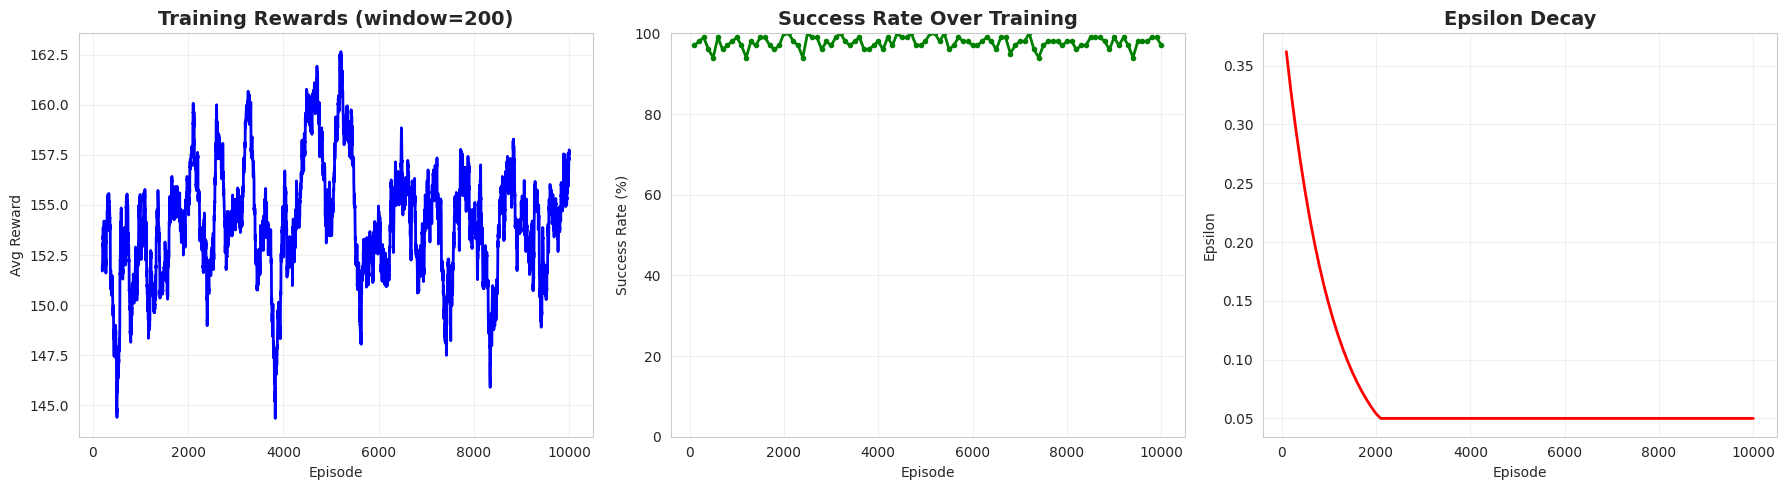

In [ ]:
# Visualize training
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

window = 200
rolling_rewards = pd.Series(episode_rewards).rolling(window).mean()
axes[0].plot(rolling_rewards, color='blue', linewidth=2)
axes[0].set_title(f'Training Rewards (window={window})', fontsize=14, weight='bold')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Avg Reward')
axes[0].grid(alpha=0.3)

axes[1].plot(range(100, len(success_rates)*100+100, 100),
             [s*100 for s in success_rates], color='green', linewidth=2, marker='o', markersize=3)
axes[1].set_title('Success Rate Over Training', fontsize=14, weight='bold')
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Success Rate (%)')
axes[1].set_ylim(0, 100)
axes[1].grid(alpha=0.3)

axes[2].plot(range(100, len(epsilon_history)*100+100, 100),
             epsilon_history, color='red', linewidth=2)
axes[2].set_title('Epsilon Decay', fontsize=14, weight='bold')
axes[2].set_xlabel('Episode')
axes[2].set_ylabel('Epsilon')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Evaluation on Test Set

In [ ]:
def evaluate_agent(agent, test_words):
    results = []

    print(f'\n Evaluating optimized agent on {len(test_words)} test games...')

    for word in tqdm(test_words):
        game = HangmanGame(word)
        state = game.get_state()
        guesses_made = []

        while not game.game_over:
            action = agent.choose_action(state, training=False)
            if action is None:
                break
            guesses_made.append(action)
            state, reward, done = game.guess(action)

        results.append({
            'word': word,
            'won': game.won,
            'wrong_guesses': game.wrong_guesses,
            'repeated_guesses': game.repeated_guesses,
            'total_guesses': len(guesses_made),
            'guesses': ''.join(guesses_made)
        })

    results_df = pd.DataFrame(results)

    wins = results_df['won'].sum()
    success_rate = wins / len(test_words)
    total_wrong = results_df['wrong_guesses'].sum()
    total_repeated = results_df['repeated_guesses'].sum()
    final_score = (success_rate * 2000) - (total_wrong * 5) - (total_repeated * 2)

    baseline_score = -56250
    improvement = final_score - baseline_score

    print(f'\n Evaluation Results:')
    print(f'   Games Won: {wins}/{len(test_words)} ({success_rate*100:.2f}%)')
    print(f'   Total Wrong Guesses: {total_wrong}')
    print(f'   Total Repeated Guesses: {total_repeated}')
    print(f'   Avg Wrong per Game: {total_wrong/len(test_words):.2f}')
    print(f'\n FINAL SCORE: {final_score:.2f}')
    print(f'\n   Formula: ({success_rate:.4f} × 2000) - ({total_wrong} × 5) - ({total_repeated} × 2)')
    print(f'            = {success_rate*2000:.2f} - {total_wrong*5} - {total_repeated*2}')
    print(f'            = {final_score:.2f}')
    print(f'\n Comparison:')
    print(f'   Baseline Score: {baseline_score:.2f}')
    print(f'   Optimized Score: {final_score:.2f}')
    print(f'   Improvement: {improvement:+.2f} points ({improvement/abs(baseline_score)*100:+.1f}%)')

    return results_df, final_score

results_df, final_score = evaluate_agent(agent, test_words)


 Evaluating optimized agent on 2000 test games...


100%|██████████| 2000/2000 [00:42<00:00, 46.55it/s]


 Evaluation Results:
   Games Won: 598/2000 (29.90%)
   Total Wrong Guesses: 10609
   Total Repeated Guesses: 0
   Avg Wrong per Game: 5.30

 FINAL SCORE: -52447.00

   Formula: (0.2990 × 2000) - (10609 × 5) - (0 × 2)
            = 598.00 - 53045 - 0
            = -52447.00

 Comparison:
   Baseline Score: -56250.00
   Optimized Score: -52447.00
   Improvement: +3803.00 points (+6.8%)


In [ ]:
# Sample results
print('\n Top 20 Results:')
display(results_df.head(20))

print('\n Won Games Sample:')
won_games = results_df[results_df['won'] == True]
if len(won_games) > 0:
    display(won_games.head(15))
else:
    print('No games won')

print(f'\n Lost Games Sample:')
display(results_df[results_df['won'] == False].head(10))


 Top 20 Results:


,word,won,wrong_guesses,repeated_guesses,total_guesses,guesses
0,marmar,True,4,0,7,eanlmtr
1,janet,False,6,0,10,ernamtlich
2,dentistical,True,2,0,11,eintschalrd
3,troveless,False,6,0,12,eslaiqtronmp
4,unnotify,False,6,0,11,eaiontcsrul
5,gastrostenosis,False,6,0,14,eistraonlcmhpd
6,preaffiliation,False,6,0,15,eintscralopmdbg
7,obpyriform,False,6,0,9,einraocts
8,veratrinize,False,6,0,13,eizrtnaldhmsp
9,protection,True,4,0,12,eintasrodlcp



 Won Games Sample:


,word,won,wrong_guesses,repeated_guesses,total_guesses,guesses
0,marmar,True,4,0,7,eanlmtr
2,dentistical,True,2,0,11,eintschalrd
9,protection,True,4,0,12,eintasrodlcp
11,phototactic,True,3,0,10,eiophtnasc
12,triloculate,True,3,0,12,eitnarcoslhu
13,trustee,True,3,0,8,etiaorsu
21,timbromaniac,True,5,0,14,eioncstarlpmub
24,catechesis,True,5,0,12,entlrsaidmch
33,observandum,True,4,0,15,eiasobrvntgdulm
35,rotaman,True,5,0,11,ealnfrtiocm



 Lost Games Sample:


,word,won,wrong_guesses,repeated_guesses,total_guesses,guesses
1,janet,False,6,0,10,ernamtlich
3,troveless,False,6,0,12,eslaiqtronmp
4,unnotify,False,6,0,11,eaiontcsrul
5,gastrostenosis,False,6,0,14,eistraonlcmhpd
6,preaffiliation,False,6,0,15,eintscralopmdbg
7,obpyriform,False,6,0,9,einraocts
8,veratrinize,False,6,0,13,eizrtnaldhmsp
10,guileless,False,6,0,10,eslaoitrnd
14,sextole,False,6,0,11,erlospntadc
15,wusp,False,6,0,8,eaoiustm


## 8. Comprehensive Analysis

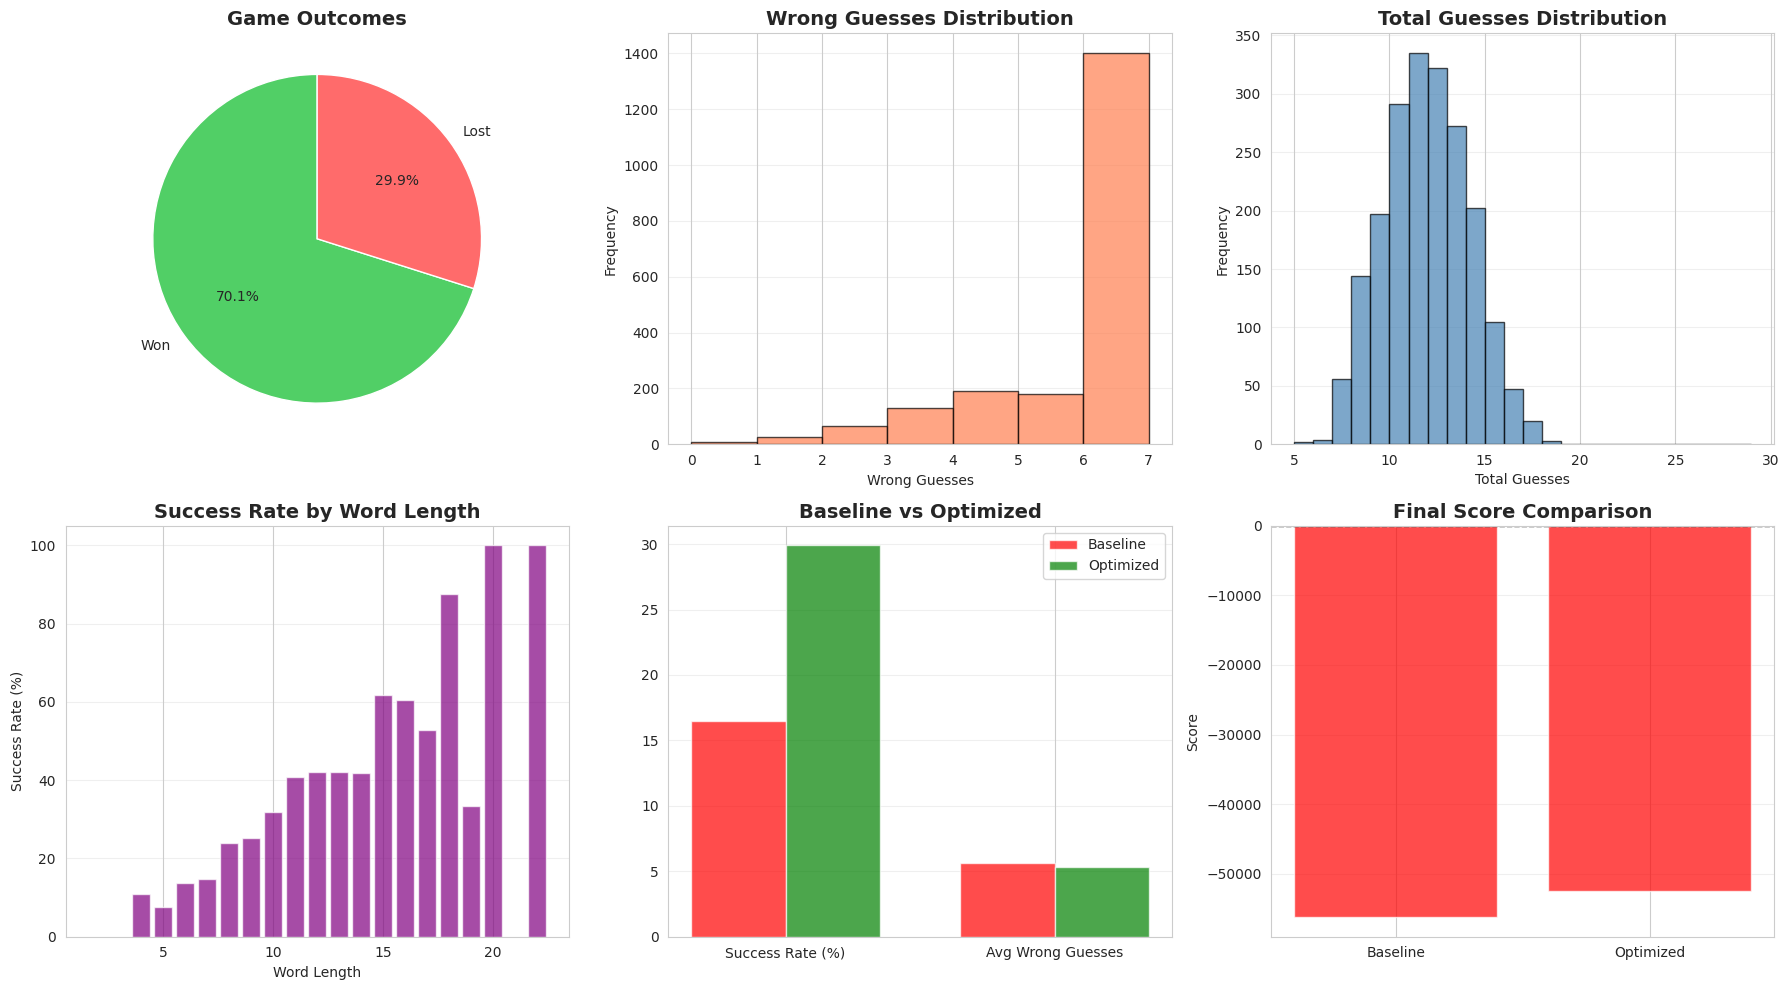

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Win/Loss pie chart
win_counts = results_df['won'].value_counts()
colors = ['#51cf66' if results_df['won'].sum() > 0 else '#ff6b6b', '#ff6b6b']
axes[0, 0].pie(win_counts.values, labels=['Won' if results_df['won'].sum() > 0 else 'Lost', 'Lost' if results_df['won'].sum() > 0 else ''],
               autopct='%1.1f%%', colors=colors, startangle=90)
axes[0, 0].set_title('Game Outcomes', fontsize=14, weight='bold')

# Wrong guesses histogram
axes[0, 1].hist(results_df['wrong_guesses'], bins=range(0, 8),
                color='coral', alpha=0.7, edgecolor='black')
axes[0, 1].set_title('Wrong Guesses Distribution', fontsize=14, weight='bold')
axes[0, 1].set_xlabel('Wrong Guesses')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].grid(axis='y', alpha=0.3)

# Total guesses histogram
axes[0, 2].hist(results_df['total_guesses'], bins=range(5, 30),
                color='steelblue', alpha=0.7, edgecolor='black')
axes[0, 2].set_title('Total Guesses Distribution', fontsize=14, weight='bold')
axes[0, 2].set_xlabel('Total Guesses')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].grid(axis='y', alpha=0.3)

# Word length analysis
results_df['word_length'] = results_df['word'].str.len()
length_success = results_df.groupby('word_length')['won'].mean() * 100
axes[1, 0].bar(length_success.index, length_success.values, color='purple', alpha=0.7)
axes[1, 0].set_title('Success Rate by Word Length', fontsize=14, weight='bold')
axes[1, 0].set_xlabel('Word Length')
axes[1, 0].set_ylabel('Success Rate (%)')
axes[1, 0].grid(axis='y', alpha=0.3)

# Comparison bar chart
comparison = pd.DataFrame({
    'Metric': ['Success Rate (%)', 'Avg Wrong Guesses'],
    'Baseline': [16.5, 5.66],
    'Optimized': [results_df['won'].mean()*100, results_df['wrong_guesses'].mean()]
})
x = np.arange(len(comparison))
width = 0.35
axes[1, 1].bar(x - width/2, comparison['Baseline'], width, label='Baseline', color='red', alpha=0.7)
axes[1, 1].bar(x + width/2, comparison['Optimized'], width, label='Optimized', color='green', alpha=0.7)
axes[1, 1].set_title('Baseline vs Optimized', fontsize=14, weight='bold')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(comparison['Metric'])
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)

# Score comparison
scores = pd.DataFrame({
    'Version': ['Baseline', 'Optimized'],
    'Score': [-56250, final_score]
})
colors_score = ['red' if s < 0 else 'green' for s in scores['Score']]
axes[1, 2].bar(scores['Version'], scores['Score'], color=colors_score, alpha=0.7)
axes[1, 2].set_title('Final Score Comparison', fontsize=14, weight='bold')
axes[1, 2].set_ylabel('Score')
axes[1, 2].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[1, 2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Save Results

In [ ]:
# Save detailed results
results_df.to_csv('hangman_optimized_results.csv', index=False)
print(' Detailed results saved: hangman_optimized_results.csv')

# Summary
summary = {
    'Version': 'Optimized',
    'Total_Games': len(results_df),
    'Games_Won': results_df['won'].sum(),
    'Success_Rate': results_df['won'].mean(),
    'Total_Wrong_Guesses': results_df['wrong_guesses'].sum(),
    'Total_Repeated_Guesses': results_df['repeated_guesses'].sum(),
    'Avg_Wrong_Guesses': results_df['wrong_guesses'].mean(),
    'Final_Score': final_score,
    'Baseline_Score': -56250,
    'Improvement': final_score - (-56250),
    'Improvement_Percent': (final_score - (-56250)) / 56250 * 100
}

summary_df = pd.DataFrame([summary])
summary_df.to_csv('hangman_optimized_summary.csv', index=False)
print(' Summary saved: hangman_optimized_summary.csv')

print(f'\n' + '='*60)
print(f' OPTIMIZED SOLUTION COMPLETE!')
print(f'='*60)
print(f' Final Results:')
print(f'   Success Rate: {summary["Success_Rate"]*100:.2f}%')
print(f'   Final Score: {final_score:.2f}')
print(f'   Improvement: {summary["Improvement"]:+.2f} points')
print(f'   ({summary["Improvement_Percent"]:+.1f}% change from baseline)')
print(f'='*60)

 Detailed results saved: hangman_optimized_results.csv
 Summary saved: hangman_optimized_summary.csv

 OPTIMIZED SOLUTION COMPLETE!
 Final Results:
   Success Rate: 29.90%
   Final Score: -52447.00
   Improvement: +3803.00 points
   (+6.8% change from baseline)


In [ ]:
from ipywidgets import widgets, VBox, HBox
from IPython.display import display, clear_output

def masked_predict_ui(mask, guessed):
    mask = mask.lower().strip()
    guessed = set(guessed.lower().strip())

    print("\n--- Masked Hangman Assistant ---")
    print(f"Masked Pattern     : {mask}")
    print(f"Guessed Letters    : {sorted(guessed)}")

    # Get matching words using your HMM
    candidates = hmm.get_matching_words(mask, guessed)
    num_candidates = len(candidates)

    print(f"\nPossible Words     : {num_candidates}")

    if num_candidates == 0:
        print("❌ No possible matches found.")
        return

    # Show candidates if small
    if num_candidates <= 12:
        print("Candidates:", candidates)

    # Score candidates to choose best predicted word
    scored = sorted(
        candidates,
        key=lambda w: sum(hmm.letter_freq[ch] for ch in w),
        reverse=True
    )
    best_word = scored[0]

    # Suggest next best letter
    best_letter = hmm.predict_letter(mask, guessed)

    print(f"\n🎯 Best Next Letter : {best_letter}")
    print(f"🏆 Predicted Word   : {best_word}\n")


# --- UI Layout ---
mask_input = widgets.Text(
    value='',
    placeholder='Example: e_on',
    description='Masked:',
    layout=widgets.Layout(width='300px')
)

guessed_input = widgets.Text(
    value='',
    placeholder='Example: eonst',
    description='Guessed:',
    layout=widgets.Layout(width='300px')
)

run_button = widgets.Button(description="Predict 🔍", button_style='success')
output = widgets.Output()

def on_button_click(b):
    with output:
        clear_output()
        masked_predict_ui(mask_input.value, guessed_input.value)

run_button.on_click(on_button_click)

display(VBox([mask_input, guessed_input, run_button, output]))